## SDV - synthetic data vault

Easiest way to use CopulaSynthesizer is via SDV.

Copula is based on gaussian methods, and it might provide statistically more accurate synthetic data (when compared to CTGAN), depending on situation.

In [55]:
# imports
import pandas as pd
import seaborn as sns
pd.set_option('display.float_format', '{:.3f}'.format)

# load the data and remove the usual unusable columns in this data
df = pd.read_csv("../houses.csv")
df = df.drop(["id", "date", "zipcode", "lat", "long"], axis=1)
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.000,3,1.000,1180,5650,1.000,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.000,3,2.250,2570,7242,2.000,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.000,2,1.000,770,10000,1.000,0,0,3,6,770,0,1933,0,2720,8062
3,604000.000,4,3.000,1960,5000,1.000,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.000,3,2.000,1680,8080,1.000,0,0,3,8,1680,0,1987,0,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.000,3,2.500,1530,1131,3.000,0,0,3,8,1530,0,2009,0,1530,1509
21609,400000.000,4,2.500,2310,5813,2.000,0,0,3,8,2310,0,2014,0,1830,7200
21610,402101.000,2,0.750,1020,1350,2.000,0,0,3,7,1020,0,2009,0,1020,2007
21611,400000.000,3,2.500,1600,2388,2.000,0,0,3,8,1600,0,2004,0,1410,1287


<Axes: xlabel='price', ylabel='Count'>

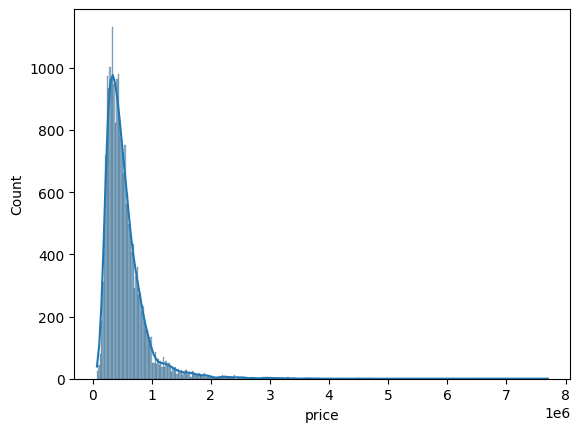

In [56]:
sns.histplot(data=df, x="price", kde=True)

<b>SDV -> GaussianCopulaSynthesizer</b>

In [57]:
# pip install sdv
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata

# sidenote: SDV + Copula can potentially use lots of RAM
# if there's a lot of original data

# current version of SDV requires a Metadata-object
# but it's enough you just wrap the DataFrame into it
metadata = Metadata.detect_from_dataframes(
    data={'houses': df}
)

# initialize the Gaussian Copula Model
model = GaussianCopulaSynthesizer(metadata)

# fit the model
model.fit(df)

# take a copy of the original data
# se we can compare how well the ML models fare
# with different levels of optimized data
original_df = df.copy()

# use the model to generate 1000 new data rows
synthetic_data = model.sample(num_rows=1000)
synthetic_data

c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,766669.000,4,3.220,3440,27874,1.800,0,0,3,8,2940,0,1964,2002,2427,27253
1,615584.000,2,2.850,2689,6654,2.800,0,0,4,8,2374,2,2006,1993,2379,11029
2,320709.000,3,2.940,2664,14102,2.300,0,0,3,8,2761,0,2013,1998,2798,8840
3,289924.000,3,1.950,1189,4858,1.800,0,0,5,8,1685,0,1927,1988,2152,7059
4,408373.000,3,1.130,697,1676,2.000,0,0,4,5,878,0,1930,1979,1588,1648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,407709.000,4,2.140,2392,41667,1.900,0,0,4,8,1908,0,1927,2003,1550,27717
996,334908.000,3,2.080,1718,4715,2.600,0,1,3,8,2131,0,2009,1997,1999,7730
997,195935.000,4,2.020,1788,14288,2.000,0,0,3,8,2160,0,1962,1906,1527,7710
998,833821.000,3,2.200,1568,8723,1.700,0,0,5,9,1098,40,1965,1996,2009,13265


In [58]:
# # combine the synthetic data with the original one
# disabled for now
# df = pd.concat([df, synthetic_data])

<Axes: xlabel='price', ylabel='Count'>

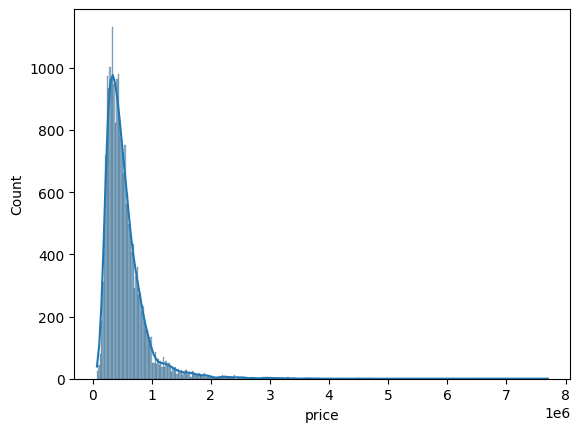

In [59]:
sns.histplot(data=df, x="price", kde=True)

<b>Version 2: Use GaussianCopulaSynthesizer to balance an important variable with synthetic data</b>

waterfront
0    21450
1      163
Name: count, dtype: int64


<Axes: xlabel='waterfront'>

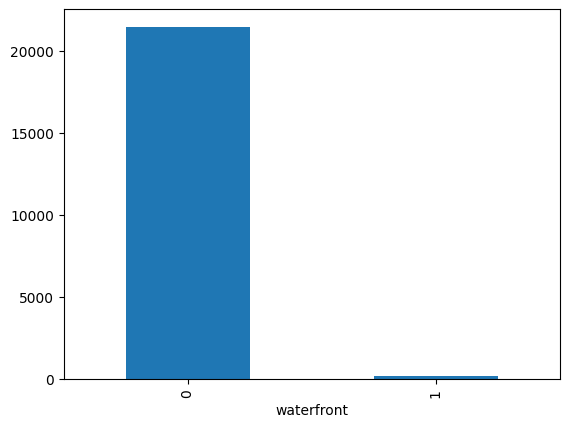

In [60]:
print(df['waterfront'].value_counts())
df['waterfront'].value_counts().plot.bar()

In [61]:
# current version of SDV requires a Metadata-object
# but it's enough you just wrap the DataFrame into it
metadata = Metadata.detect_from_dataframes(
    data={'houses': df}
)

# initialize the Gaussian Copula Model
model = GaussianCopulaSynthesizer(metadata)

# waterfront 1 is super underrepresented , only 168 rows 
# (compared to 22k+). filter out only the waterfront houses
minority_data = df[df['waterfront'] == 1]
minority_data

c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
49,1350000.000,3,2.500,2753,65005,1.000,1,2,5,9,2165,588,1953,0,2680,72513
230,655000.000,2,1.750,1450,15798,2.000,1,4,3,7,1230,220,1915,1978,2030,13193
246,2400000.000,4,2.500,3650,8354,1.000,1,4,3,9,1830,1820,2000,0,3120,18841
264,369900.000,1,0.750,760,10079,1.000,1,4,5,5,760,0,1936,0,1230,14267
300,3075000.000,4,5.000,4550,18641,1.000,1,4,3,10,2600,1950,2002,0,4550,19508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19984,1898000.000,3,2.500,2830,4334,3.000,1,4,3,10,2830,0,2006,0,2830,38211
20325,3000000.000,3,3.500,4410,10756,2.000,1,4,3,11,3430,980,2014,0,3550,5634
20767,2300000.000,4,4.000,4360,8175,2.500,1,4,3,10,3940,420,2007,0,2670,8525
21201,2230000.000,3,3.500,3760,5634,2.000,1,4,3,11,2830,930,2014,0,3560,5762


In [62]:
# we can also generate a huge amount of new houses
# and only filter out minority class data out of it
# in this case => waterfront 1
# we need to generate a lot of data
# because only a very small fraction of the new data
# is going to be waterfront 1
model = GaussianCopulaSynthesizer(metadata)
model.fit(df)

# we have to generate a ridiculous amount of data
# because the original dataset only has 168 watefront buildings
# against 22445 non-waterfront buildings
# this means: when you generate 300000 buildings, only a small
# fraction is going to be new waterfronts
synthetic_waterfronts = model.sample(400000)
synthetic_minority_data = synthetic_waterfronts[synthetic_waterfronts['waterfront'] == 1]


In [63]:
synthetic_minority_data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
131,827934.000,2,1.400,706,9815,1.600,1,0,3,7,641,572,1928,1990,1337,2501
155,411814.000,2,1.540,1238,24665,2.300,1,0,3,7,1321,0,1973,1987,2010,18121
590,224387.000,2,0.980,1340,31317,1.600,1,0,4,8,1245,98,1944,2007,1544,16945
639,489051.000,2,1.240,1275,45254,1.600,1,0,3,6,1014,31,1929,1976,1294,29432
740,788661.000,2,2.250,1846,1776,2.100,1,0,3,9,1466,148,2000,2006,1738,1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399384,491732.000,4,2.680,2964,5565,2.700,1,0,4,8,1996,166,2009,1952,1940,8024
399401,342267.000,2,1.670,1536,19683,1.600,1,0,5,8,1964,0,1976,1946,2050,12196
399801,664788.000,3,1.120,1188,1528,1.500,1,1,3,9,867,148,1915,2003,1637,966
399914,549594.000,5,1.800,2538,3661,1.800,1,0,5,9,2136,510,1964,1974,2127,4664


In [64]:
model = GaussianCopulaSynthesizer(metadata)
model.fit(df)

# we have to generate a ridiculous amount of data
# because the original dataset only has 168 watefront buildings
# against 22445 non-waterfront buildings
# this means: when you generate 300000 buildings, only a small
# fraction is going to be new waterfronts
synthetic_views = model.sample(40000)
synthetic_minority_data_view = synthetic_views[synthetic_views['view'] != 0]

In [65]:
# synthetic_minority_data['waterfront'].value_counts()

In [66]:
synthetic_minority_data_view['view'].value_counts()

view
2    1791
3     972
1     646
4     638
Name: count, dtype: int64

In [67]:
# synthetic_minority_data

In [68]:
# sns.histplot(data=synthetic_minority_data, x="price", kde=True)

In [69]:
# waterfront has a considerable bigger correlation price now
# since we added more data and it was almost non-existent
# in the beginning 
df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
price,1.000,0.308,0.525,0.702,0.090,0.257,0.266,0.397,0.036,0.667,0.606,0.324,0.054,0.126,0.585,0.082
bedrooms,0.308,1.000,0.516,0.577,0.032,0.175,-0.007,0.080,0.028,0.357,0.478,0.303,0.154,0.019,0.392,0.029
bathrooms,0.525,0.516,1.000,0.755,0.088,0.501,0.064,0.188,-0.125,0.665,0.685,0.284,0.506,0.051,0.569,0.087
sqft_living,0.702,0.577,0.755,1.000,0.173,0.354,0.104,0.285,-0.059,0.763,0.877,0.435,0.318,0.055,0.756,0.183
sqft_lot,0.090,0.032,0.088,0.173,1.000,-0.005,0.022,0.075,-0.009,0.114,0.184,0.015,0.053,0.008,0.145,0.719
floors,0.257,0.175,0.501,0.354,-0.005,1.000,0.024,0.029,-0.264,0.458,0.524,-0.246,0.489,0.006,0.280,-0.011
waterfront,0.266,-0.007,0.064,0.104,0.022,0.024,1.000,0.402,0.017,0.083,0.072,0.081,-0.026,0.093,0.086,0.031
view,0.397,0.080,0.188,0.285,0.075,0.029,0.402,1.000,0.046,0.251,0.168,0.277,-0.053,0.104,0.280,0.073
condition,0.036,0.028,-0.125,-0.059,-0.009,-0.264,0.017,0.046,1.000,-0.145,-0.158,0.174,-0.361,-0.061,-0.093,-0.003
grade,0.667,0.357,0.665,0.763,0.114,0.458,0.083,0.251,-0.145,1.000,0.756,0.168,0.447,0.014,0.713,0.119


In [70]:
df = pd.concat([df, synthetic_minority_data, synthetic_minority_data_view])
#df = pd.concat([df, synthetic_minority_data_view])

waterfront
0    25461
1     3371
Name: count, dtype: int64


<Axes: xlabel='waterfront'>

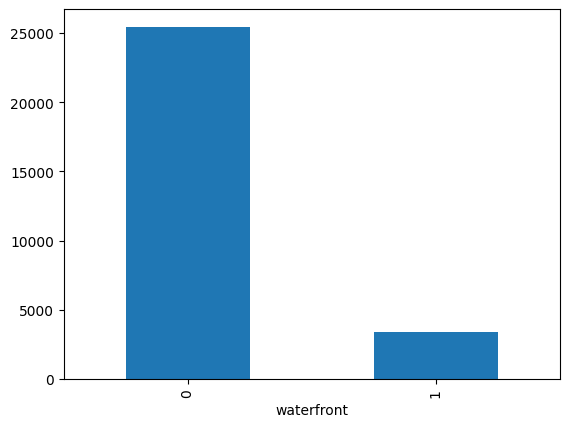

In [71]:
print(df['waterfront'].value_counts())
df['waterfront'].value_counts().plot.bar()

view
0    22309
2     2925
3     1556
1     1042
4     1000
Name: count, dtype: int64


<Axes: xlabel='view'>

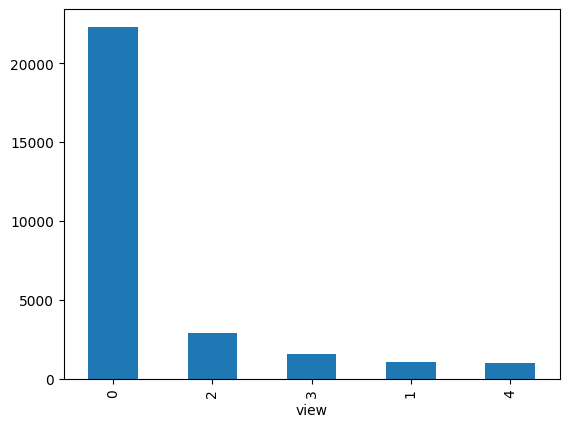

In [72]:
print(df['view'].value_counts())
df['view'].value_counts().plot.bar()

<Axes: >

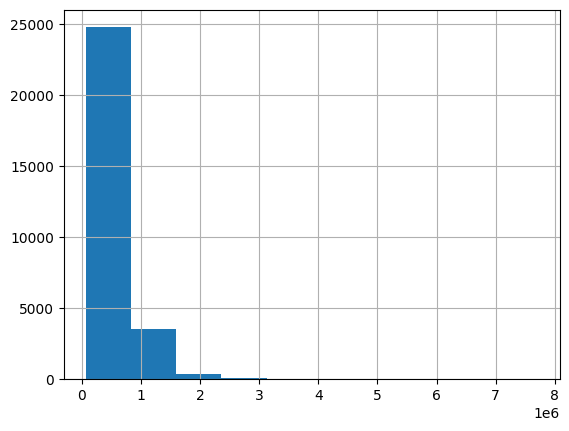

In [73]:
df['price'].hist()

In [74]:
df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
price,1.000,0.308,0.525,0.688,0.089,0.269,0.068,0.278,0.029,0.665,0.600,0.283,0.061,0.120,0.587,0.084
bedrooms,0.308,1.000,0.513,0.573,0.039,0.167,-0.005,0.065,0.022,0.353,0.480,0.259,0.154,0.029,0.389,0.038
bathrooms,0.525,0.513,1.000,0.749,0.083,0.472,0.011,0.133,-0.115,0.659,0.683,0.246,0.502,0.054,0.569,0.083
sqft_living,0.688,0.573,0.749,1.000,0.170,0.348,0.023,0.199,-0.052,0.749,0.867,0.357,0.312,0.082,0.747,0.182
sqft_lot,0.089,0.039,0.083,0.170,1.000,-0.009,0.010,0.049,-0.004,0.111,0.185,0.009,0.041,0.012,0.154,0.728
floors,0.269,0.167,0.472,0.348,-0.009,1.000,0.258,0.225,-0.213,0.435,0.493,-0.270,0.441,0.398,0.291,-0.010
waterfront,0.068,-0.005,0.011,0.023,0.010,0.258,1.000,-0.031,0.008,0.019,0.022,-0.088,-0.010,0.551,0.032,0.016
view,0.278,0.065,0.133,0.199,0.049,0.225,-0.031,1.000,0.027,0.181,0.121,0.093,-0.048,0.471,0.201,0.053
condition,0.029,0.022,-0.115,-0.052,-0.004,-0.213,0.008,0.027,1.000,-0.129,-0.139,0.145,-0.313,-0.015,-0.078,0.001
grade,0.665,0.353,0.659,0.749,0.111,0.435,0.019,0.181,-0.129,1.000,0.744,0.135,0.434,0.060,0.700,0.120


In [75]:
len(df)

28832

In [76]:
df = df.drop_duplicates()

In [77]:
# originall from AI just to test a quick downsampling
N = 5000
downsampled_df = df.groupby('view').apply(lambda x: x.sample(n=min(len(x), N))).reset_index(drop=True)


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_21660\726502983.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [78]:
downsampled_df['view'].value_counts()

view
0    5000
2    2915
3    1544
1    1035
4     992
Name: count, dtype: int64

In [79]:
downsampled_df['waterfront'].value_counts()

waterfront
0    10317
1     1169
Name: count, dtype: int64

In [80]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000,28790.000
mean,556873.048,3.384,2.132,2119.047,15311.519,1.636,0.116,0.537,3.412,7.698,1807.130,255.958,1970.553,559.723,2014.751,13037.653
std,357372.679,0.939,0.776,991.650,36823.751,0.573,0.320,1.089,0.651,1.208,823.062,420.116,29.487,895.014,690.954,24573.852
min,75000.000,0.000,0.000,290.000,520.000,1.000,0.000,0.000,1.000,1.000,290.000,0.000,1900.000,0.000,399.000,651.000
25%,330000.000,3.000,1.630,1410.000,5000.000,1.000,0.000,0.000,3.000,7.000,1204.250,0.000,1950.000,0.000,1510.000,5000.000
50%,472546.000,3.000,2.250,1940.000,7899.000,1.700,0.000,0.000,3.000,8.000,1600.000,0.000,1974.000,0.000,1880.000,7800.000
75%,678660.250,4.000,2.500,2630.000,12696.000,2.000,0.000,0.000,4.000,8.000,2248.000,440.000,1996.000,1959.000,2400.000,11478.500
max,7700000.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,2015.000,6210.000,871200.000


In [81]:
# original_df2.describe()

In [82]:
original_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000,21613.000
mean,540088.142,3.371,2.115,2079.900,15106.968,1.494,0.008,0.234,3.409,7.657,1788.391,291.509,1971.005,84.402,1986.552,12768.456
std,367127.196,0.930,0.770,918.441,41420.512,0.540,0.087,0.766,0.651,1.175,828.091,442.575,29.373,401.679,685.391,27304.180
min,75000.000,0.000,0.000,290.000,520.000,1.000,0.000,0.000,1.000,1.000,290.000,0.000,1900.000,0.000,399.000,651.000
25%,321950.000,3.000,1.750,1427.000,5040.000,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951.000,0.000,1490.000,5100.000
50%,450000.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,1840.000,7620.000
75%,645000.000,4.000,2.500,2550.000,10688.000,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997.000,0.000,2360.000,10083.000
max,7700000.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,2015.000,6210.000,871200.000


## Benchmarking - try training a ML model with the different versions of data

**Version 1: Original DataFrame**

In [83]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import xgboost as xgb

# X/y 
X = original_df.drop("price", axis=1)
y = original_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model1 = xgb.XGBRegressor(objective='reg:squarederror')
#model1 = LinearRegression()
model1.fit(X_train, y_train)
predictions = model1.predict(X_test)

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))



RMSE:
187236.93 $

R-squared:
0.76


In [84]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# X/y 
X = df.drop("price", axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model1 = xgb.XGBRegressor(objective='reg:squarederror')
##model1 = LinearRegression()
model1.fit(X_train, y_train)
predictions = model1.predict(X_test)

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))



RMSE:
195170.9 $

R-squared:
0.7


In [85]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# X/y 
X = downsampled_df.drop("price", axis=1)
y = downsampled_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model1 = xgb.XGBRegressor(objective='reg:squarederror')
#model1 = LinearRegression()
model1.fit(X_train, y_train)
predictions = model1.predict(X_test)

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))



RMSE:
225197.79 $

R-squared:
0.68
